In [3]:
import nltk
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('maxent_ne_chunker_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\ritik\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\ritik\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package maxent_ne_chunker_tab to
[nltk_data]     C:\Users\ritik\AppData\Roaming\nltk_data...
[nltk_data]   Package maxent_ne_chunker_tab is already up-to-date!


True

In [4]:
import pandas as pd

In [5]:
# Load the Amazon reviews dataset into a pandas DataFrame.
df=pd.read_csv("Reviews.csv")

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

import nltk
text="I love this product"
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')
nltk.download('maxent_ne_chunker')
nltk.download('words')
nltk.download('vader_lexicon')
example = df['Text'].iloc[50]
tokens = nltk.word_tokenize(example)
tagged = nltk.pos_tag(tokens)
entities = nltk.chunk.ne_chunk(tagged)

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ritik\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\ritik\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package maxent_ne_chunker to
[nltk_data]     C:\Users\ritik\AppData\Roaming\nltk_data...
[nltk_data]   Package maxent_ne_chunker is already up-to-date!
[nltk_data] Downloading package words to
[nltk_data]     C:\Users\ritik\AppData\Roaming\nltk_data...
[nltk_data]   Package words is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\ritik\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [7]:
df.shape

(568454, 10)

In [8]:
df.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [9]:
#EDA: understand the data before applying sentiment models.

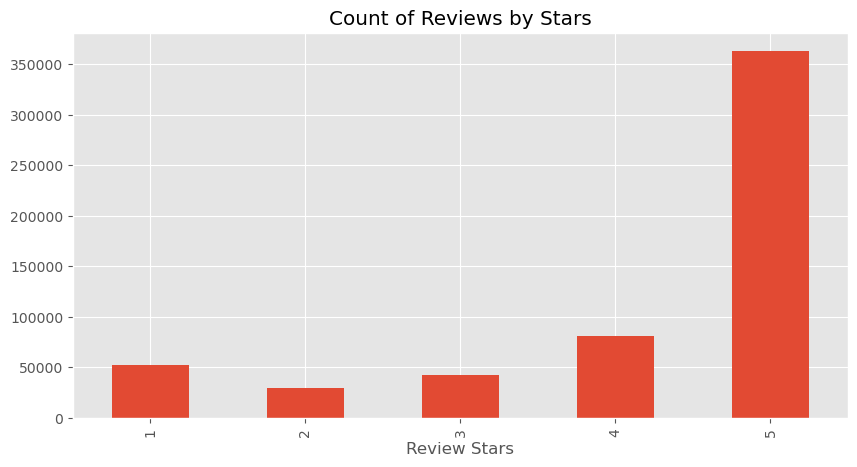

In [10]:
ax = df['Score'].value_counts().sort_index() \
    .plot(kind='bar',
          title='Count of Reviews by Stars',
          figsize=(10, 5))
ax.set_xlabel('Review Stars')
plt.show()

In [11]:
# Basic NLTK processing: tokenization, POS tagging, and named entity recognition.

In [12]:
example=df["Text"][50]

In [13]:
example

"This oatmeal is not good. Its mushy, soft, I don't like it. Quaker Oats is the way to go."

In [14]:
# Tokenize the example review into individual words and punctuation marks.
tokens = nltk.word_tokenize(example)

# Display the first 10 tokens to verify tokenization.
tokens[:10]


['This', 'oatmeal', 'is', 'not', 'good', '.', 'Its', 'mushy', ',', 'soft']

In [15]:
# Apply part-of-speech tagging to the tokens.
tagged = nltk.pos_tag(tokens)

# Display the first 10 tagged tokens.
tagged[:10]

[('This', 'DT'),
 ('oatmeal', 'NN'),
 ('is', 'VBZ'),
 ('not', 'RB'),
 ('good', 'JJ'),
 ('.', '.'),
 ('Its', 'PRP$'),
 ('mushy', 'NN'),
 (',', ','),
 ('soft', 'JJ')]

In [16]:
# Perform named entity recognition on the tagged words.
entities = nltk.chunk.ne_chunk(tagged)

# Print the entity tree in a readable format.
entities.pprint()

(S
  This/DT
  oatmeal/NN
  is/VBZ
  not/RB
  good/JJ
  ./.
  Its/PRP$
  mushy/NN
  ,/,
  soft/JJ
  ,/,
  I/PRP
  do/VBP
  n't/RB
  like/VB
  it/PRP
  ./.
  (ORGANIZATION Quaker/NNP Oats/NNPS)
  is/VBZ
  the/DT
  way/NN
  to/TO
  go/VB
  ./.)


In [17]:
# Step 1: VADER Sentiment Scoring.
# VADER is a lexicon/rule-based sentiment analyzer that works well on short text and reviews

In [18]:
# Import the VADER sentiment analyzer and tqdm for progress bars.

In [19]:
from nltk.sentiment import SentimentIntensityAnalyzer
from tqdm.notebook import tqdm

sia = SentimentIntensityAnalyzer()

In [20]:
sia.polarity_scores('I am so happy!')

{'neg': 0.0, 'neu': 0.318, 'pos': 0.682, 'compound': 0.6468}

In [21]:
sia.polarity_scores('This is the worst thing ever.')

{'neg': 0.451, 'neu': 0.549, 'pos': 0.0, 'compound': -0.6249}

In [22]:
sia.polarity_scores(example)

{'neg': 0.22, 'neu': 0.78, 'pos': 0.0, 'compound': -0.5448}

In [23]:
# Run VADER polarity scoring on the entire dataset.

In [24]:
# Store VADER scores for every review using the review Id as the key.
res = {}
for i, row in tqdm(df.iterrows(), total=len(df)):
    text = row['Text']
    myid = row['Id']
    res[myid] = sia.polarity_scores(text)

  0%|          | 0/568454 [00:00<?, ?it/s]

In [25]:
# Convert the VADER result dictionary into a DataFrame.
vaders = pd.DataFrame(res).T
# Move the review Id from the index into a normal column.
vaders = vaders.reset_index().rename(columns={'index': 'Id'})
# Merge VADER sentiment scores back with the original review data.
vaders = vaders.merge(df, how='left')

In [26]:
vaders.head()

,Id,neg,neu,pos,compound,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,0.000,0.695,0.305,0.9441,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,0.138,0.862,0.000,-0.5664,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,0.091,0.754,0.155,0.8265,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,0.000,1.000,0.000,0.0000,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,0.000,0.552,0.448,0.9468,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [27]:
# Plot VADER results to see how sentiment scores change with star ratings.

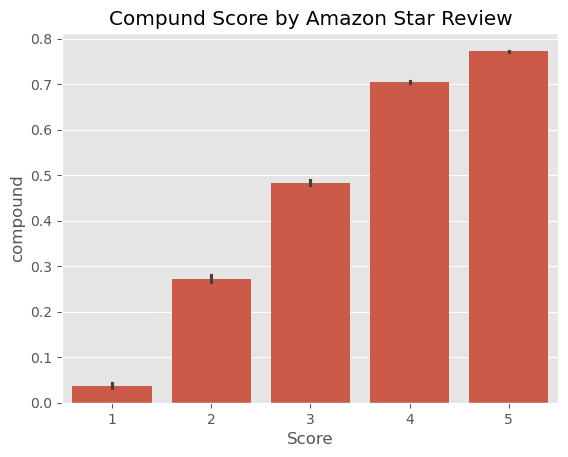

In [28]:
# Plot VADER results to see how sentiment scores change with star ratings.
ax = sns.barplot(data=vaders, x='Score', y='compound')
ax.set_title('Compund Score by Amazon Star Review')
plt.show()

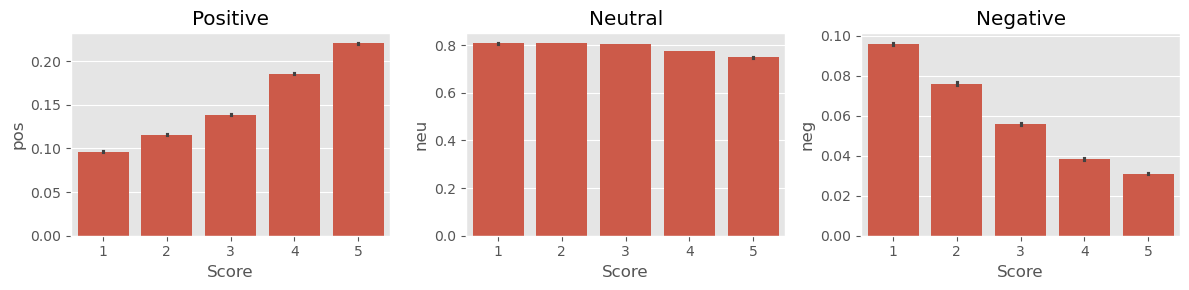

In [29]:
# Plot VADER positive, neutral, and negative scores separately for each star rating.
fig, axs = plt.subplots(1, 3, figsize=(12, 3))
sns.barplot(data=vaders, x='Score', y='pos', ax=axs[0])
sns.barplot(data=vaders, x='Score', y='neu', ax=axs[1])
sns.barplot(data=vaders, x='Score', y='neg', ax=axs[2])
axs[0].set_title('Positive')
axs[1].set_title('Neutral')
axs[2].set_title('Negative')
plt.tight_layout()
plt.show()

In [30]:
# Step 2: RoBERTa Pretrained Model.
# RoBERTa is a transformer model trained on a large text corpus.
# Unlike VADER, it considers word context, so it can often understand complex sentiment better.


In [31]:
import sys
!{sys.executable} -m pip install transformers torch scipy

In [32]:
from transformers import AutoTokenizer
from transformers import AutoModelForSequenceClassification
from scipy.special import softmax

In [33]:
# Load the pretrained RoBERTa sentiment model and its tokenizer.
MODEL = f"cardiffnlp/twitter-roberta-base-sentiment"
tokenizer = AutoTokenizer.from_pretrained(MODEL)
model = AutoModelForSequenceClassification.from_pretrained(MODEL)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [34]:
# VADER RESULT ON A TRIAL EXAMPLE

In [35]:
print(example)
sia.polarity_scores(example)

This oatmeal is not good. Its mushy, soft, I don't like it. Quaker Oats is the way to go.


{'neg': 0.22, 'neu': 0.78, 'pos': 0.0, 'compound': -0.5448}

In [36]:
# RUN FOR ROBERTA MODEL

In [37]:
# Tokenize the review text into the format expected by the RoBERTa model.
encoded_text = tokenizer(example, return_tensors='pt')
# Pass the encoded text through the model.
output = model(**encoded_text)
# Extract raw scores from the model output.
scores = output[0][0].detach().numpy()
# Convert raw scores into probabilities for negative, neutral, and positive classes.
scores = softmax(scores)

# Store RoBERTa probabilities in a dictionary.
scores_dict = {
    'roberta_neg' : scores[0],
    'roberta_neu' : scores[1],
    'roberta_pos' : scores[2]
}
print(scores_dict)

{'roberta_neg': np.float32(0.97635514), 'roberta_neu': np.float32(0.020687466), 'roberta_pos': np.float32(0.0029573706)}


In [38]:
# Define a reusable function to calculate RoBERTa sentiment scores for any review.
def polarity_scores_roberta(example):
    encoded_text = tokenizer(example, return_tensors='pt')
    output = model(**encoded_text)
    scores = output[0][0].detach().numpy()
    scores = softmax(scores)
    scores_dict = {
        'roberta_neg' : scores[0],
        'roberta_neu' : scores[1],
        'roberta_pos' : scores[2]
    }
    return scores_dict

In [39]:
# Take a random sample of 5000 reviews to reduce processing time for RoBERTa.
# random_state makes the sample reproducible every time the notebook runs.
df = df.sample(5000, random_state=42)

In [40]:
# Run both VADER and RoBERTa sentiment scoring on the sampled reviews.
res = {}
for i, row in tqdm(df.iterrows(), total=len(df)):
    try:
        text = row['Text']
        myid = row['Id']
        vader_result = sia.polarity_scores(text)
        vader_result_rename = {}
        for key, value in vader_result.items():
            vader_result_rename[f"vader_{key}"] = value
        roberta_result = polarity_scores_roberta(text)
        both = {**vader_result_rename, **roberta_result}
        res[myid] = both
    except RuntimeError:
        print(f'Broke for id {myid}')

  0%|          | 0/5000 [00:00<?, ?it/s]

Broke for id 184619
Broke for id 31994
Broke for id 171315
Broke for id 149020
Broke for id 366169
Broke for id 159236
Broke for id 282917
Broke for id 224275
Broke for id 157118
Broke for id 280809
Broke for id 52278
Broke for id 205204
Broke for id 14042
Broke for id 175497
Broke for id 57164
Broke for id 88051
Broke for id 126740
Broke for id 278863
Broke for id 409806
Broke for id 182582
Broke for id 330358
Broke for id 242726
Broke for id 193649
Broke for id 165555
Broke for id 270552
Broke for id 550372
Broke for id 497902
Broke for id 4307
Broke for id 466145
Broke for id 139315
Broke for id 492330
Broke for id 146856
Broke for id 410247
Broke for id 105975
Broke for id 58898
Broke for id 347875
Broke for id 468231
Broke for id 381509
Broke for id 58037
Broke for id 243163
Broke for id 245896
Broke for id 354404
Broke for id 523940
Broke for id 403318
Broke for id 44498


In [41]:
# Convert combined model results into a DataFrame.
results_df = pd.DataFrame(res).T
results_df = results_df.reset_index().rename(columns={'index': 'Id'})
results_df = results_df.merge(df, how='left')

In [42]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

In [43]:
# convert actual star rating to sentiment e.g.
#1 or 2 = negative
# 3 = neutral
# 4 or5 = positive

In [44]:
# Function to convert review star rating into a sentiment category.
def star_to_sentiment(score):
    if score <= 2:
        return "negative"
    elif score == 3:
        return "neutral"
    else:
        return "positive"

In [45]:
results_df["Actual_Sentiment"] = results_df["Score"].apply(star_to_sentiment)

In [46]:
# Convert VADER compound score into sentiment labels:
# compound >= 0.05 means positive
# compound <= -0.05 means negative
# values between -0.05 and 0.05 mean neutral

In [47]:
# Function to convert VADER compound score into a sentiment category.
def vader_to_sentiment(compound):
    if compound >= 0.05:
        return "positive"
    elif compound <= -0.05:
        return "negative"
    else:
        return "neutral"

In [48]:
results_df["VADER_Sentiment"] = results_df["vader_compound"].apply(vader_to_sentiment)

In [49]:
# Convert RoBERTa probability scores into sentiment labels.
# The sentiment class with the highest probability is selected as the final prediction.

In [50]:
# Columns containing RoBERTa probabilities for negative, neutral, and positive sentiment
roberta_cols = ["roberta_neg", "roberta_neu", "roberta_pos"]

# Select the RoBERTa column with the highest probability for each review.
results_df["RoBERTa_Sentiment"] = results_df[roberta_cols].idxmax(axis=1)

# Convert RoBERTa column names into readable sentiment labels.
results_df["RoBERTa_Sentiment"] = results_df["RoBERTa_Sentiment"].map({
    "roberta_neg": "negative",
    "roberta_neu": "neutral",
    "roberta_pos": "positive"
})

In [51]:
# Use confusion matrices to compare model predictions against star-rating-based sentiment labels.

In [52]:
labels = ["negative", "neutral", "positive"]

In [53]:
# VADER confusion matrix.

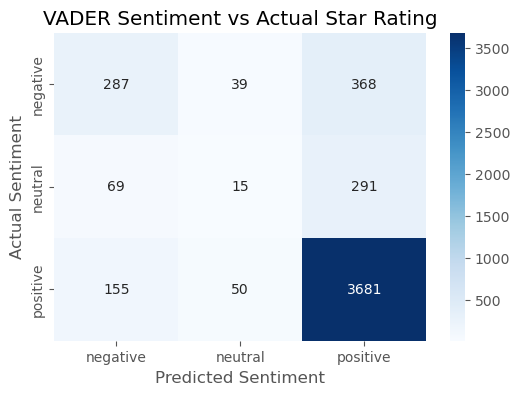

In [54]:
vader_cm = confusion_matrix(
    results_df["Actual_Sentiment"],
    results_df["VADER_Sentiment"],
    labels=labels
)
plt.figure(figsize=(6, 4))
sns.heatmap(
    vader_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)
plt.title("VADER Sentiment vs Actual Star Rating")
plt.xlabel("Predicted Sentiment")
plt.ylabel("Actual Sentiment")
plt.show()

In [55]:
# Print precision, recall, F1-score, and support for VADER predictions.
print("VADER Classification Report")
print(classification_report(
    results_df["Actual_Sentiment"],
    results_df["VADER_Sentiment"],
    labels=labels
))

VADER Classification Report
              precision    recall  f1-score   support

    negative       0.56      0.41      0.48       694
     neutral       0.14      0.04      0.06       375
    positive       0.85      0.95      0.89      3886

    accuracy                           0.80      4955
   macro avg       0.52      0.47      0.48      4955
weighted avg       0.75      0.80      0.77      4955



In [56]:
# RoBERTa confusion matrix.

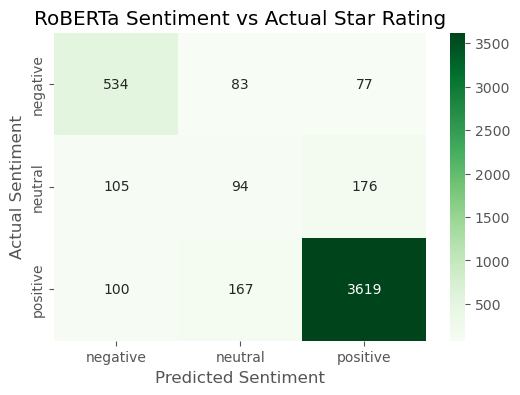

In [57]:
roberta_cm = confusion_matrix(
    results_df["Actual_Sentiment"],
    results_df["RoBERTa_Sentiment"],
    labels=labels
)

plt.figure(figsize=(6, 4))
sns.heatmap(
    roberta_cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=labels,
    yticklabels=labels
)
plt.title("RoBERTa Sentiment vs Actual Star Rating")
plt.xlabel("Predicted Sentiment")
plt.ylabel("Actual Sentiment")
plt.show()

In [58]:
# Print precision, recall, F1-score, and support for RoBERTa predictions.
print("RoBERTa Classification Report")
print(classification_report(
    results_df["Actual_Sentiment"],
    results_df["RoBERTa_Sentiment"],
    labels=labels
))

RoBERTa Classification Report
              precision    recall  f1-score   support

    negative       0.72      0.77      0.75       694
     neutral       0.27      0.25      0.26       375
    positive       0.93      0.93      0.93      3886

    accuracy                           0.86      4955
   macro avg       0.64      0.65      0.65      4955
weighted avg       0.85      0.86      0.86      4955



In [59]:
# Compare sentiment scores between VADER and RoBERTa models.

In [60]:
results_df.columns

Index(['Id', 'vader_neg', 'vader_neu', 'vader_pos', 'vader_compound',
       'roberta_neg', 'roberta_neu', 'roberta_pos', 'ProductId', 'UserId',
       'ProfileName', 'HelpfulnessNumerator', 'HelpfulnessDenominator',
       'Score', 'Time', 'Summary', 'Text', 'Actual_Sentiment',
       'VADER_Sentiment', 'RoBERTa_Sentiment'],
      dtype='str')

In [61]:
# Step 3: Combine and compare VADER and RoBERTa score distributions.

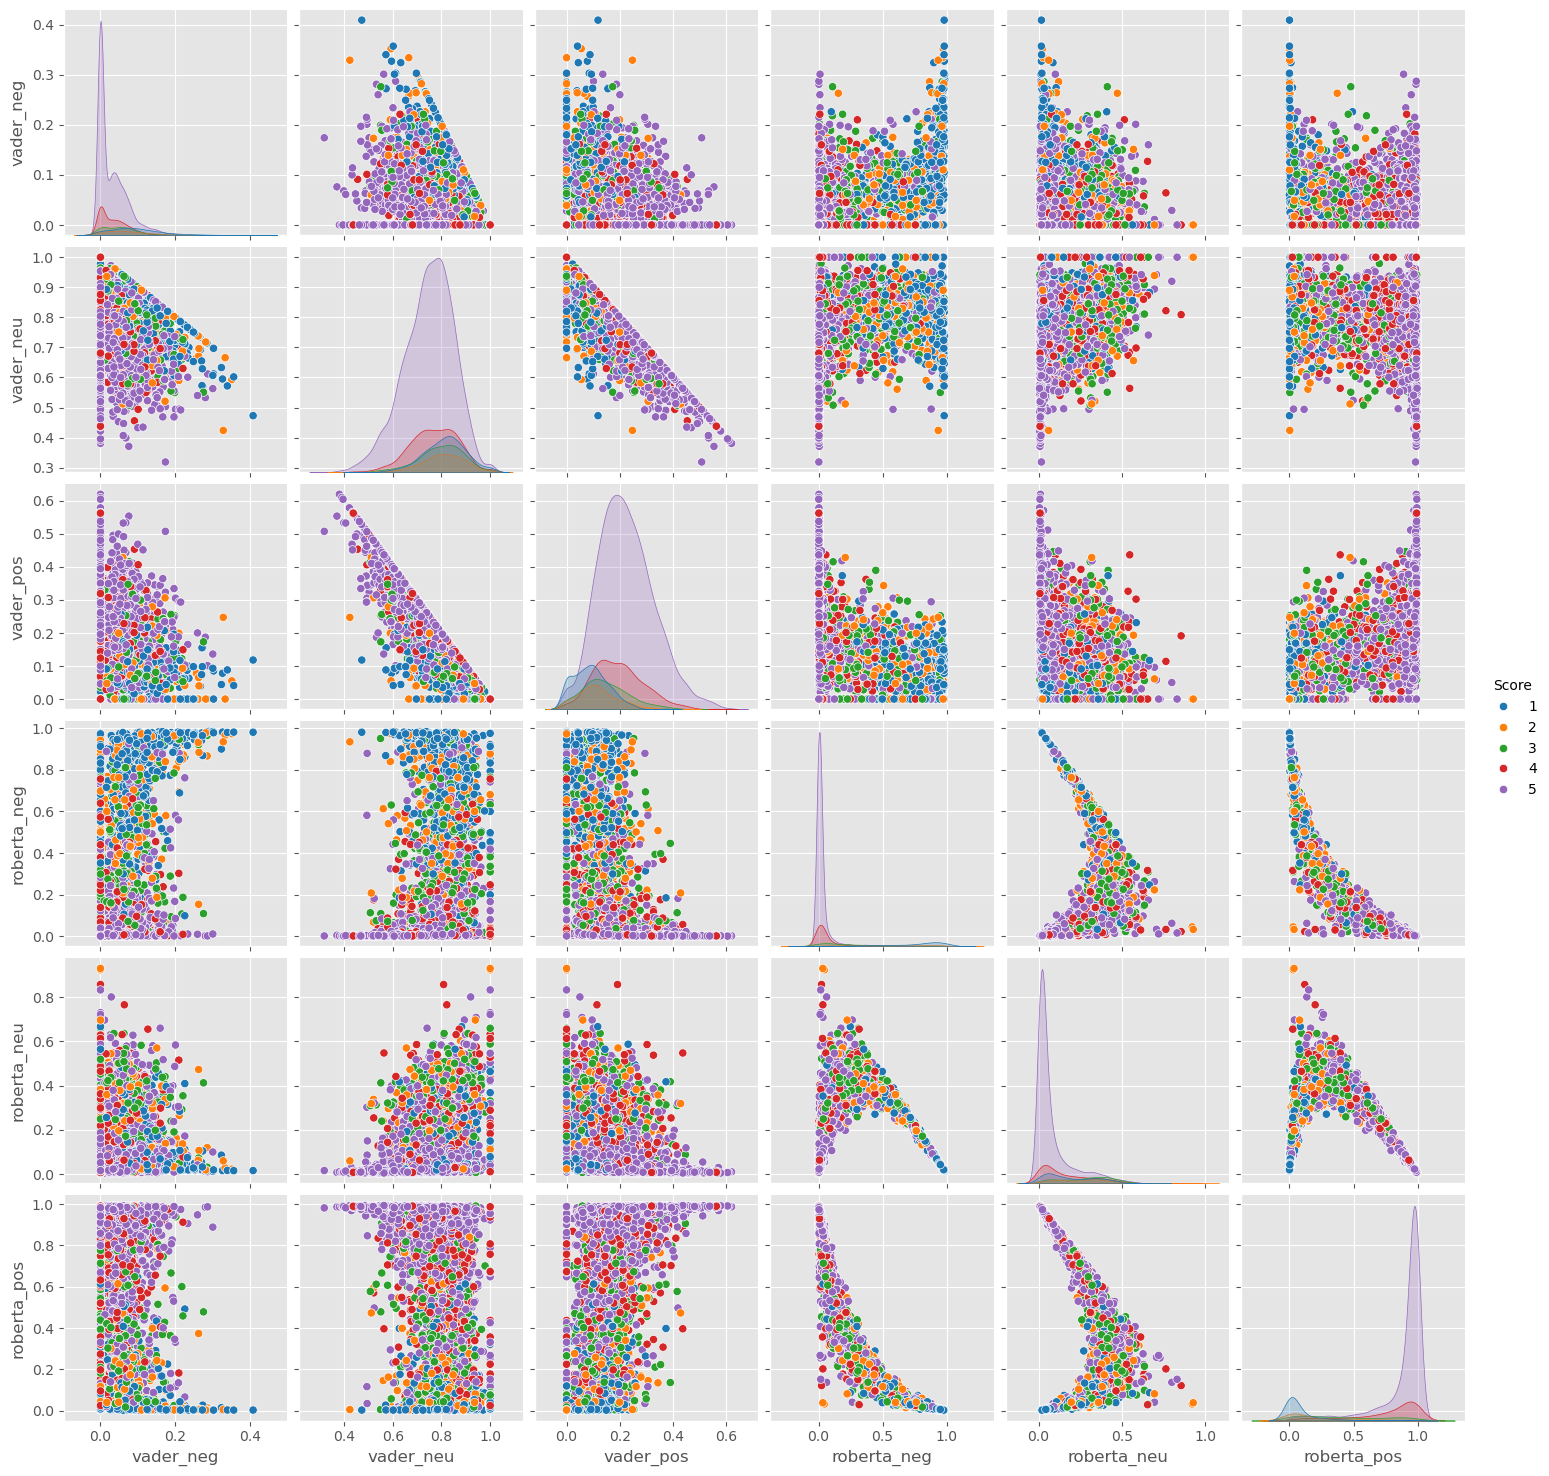

In [62]:
# Pairplot helps visualize relationships between VADER and RoBERTa sentiment scores.
# The color represents the original star rating.
sns.pairplot(data=results_df,
             vars=['vader_neg', 'vader_neu', 'vader_pos',
                  'roberta_neg', 'roberta_neu', 'roberta_pos'],
            hue='Score',
            palette='tab10')
plt.show()

In [63]:
# Step 4: Review examples where model predictions may differ from star ratings.

In [64]:
# Find a 1-star review that RoBERTa still scored highly positive.
# This can reveal sarcasm, labeling mismatch, or model confusion.
results_df.query('Score == 1') \
    .sort_values('roberta_pos', ascending=False)['Text'].values[0]

'As I stated above, this is a great product for cats.  My four cats, some old some young, love it.  Especially my 5 years old male tabby.<br /><br />And, the store shipping the product is really fast.  Thank you...my cats George and Gracie thank you.<br />Carol Sheats'

In [65]:
# Find a 1-star review that VADER scored highly positive.
# This helps identify cases where positive words appear in an overall negative review
results_df.query('Score == 1') \
    .sort_values('vader_pos', ascending=False)['Text'].values[0]

'UPDATE: BUT 5 stars GO TO AMAZON WHO ISSUED A CREDIT FOR MY LAST ORDER OF THIS PRODUCT! GOOD WORK AND THANK YOU AMAZON, I AM IMPRESSED!!! -Mo<br />..........................................<br /><br />(change from 5 stars to 1) CANCEL THIS PRAISE OF THIS PRODUCT! It DOES contain BPA! -Mo<br />..........................................<br /><br />This is *great* fish; no BPA, no added salt (*I* choose what and if salt is added), I LOVE lots of eatable fish bones (top calcium availability), congratulations Crown Prince and thank you for canning fish I can eat without BPA!'

In [66]:
# Find a 5-star review that RoBERTa scored highly negative.
# This helps inspect possible errors or reviews with mixed sentiment.
results_df.query('Score == 5') \
    .sort_values('roberta_neg', ascending=False)['Text'].values[0]

'These are the same product as the Bite-Size in the smaller blue bag except that they\'re longer links and vary in length.<br /><br />The ingredient list is somewhat gross as it lists specific parts of the pig.  If you can get past that, the taste is unmatched!<br /><br />The Slim-Jim ingredient list was similarly disturbing to me as Slim-Jim has, as separate ingredients "chicken" and "mechanically-separated chicken."  I don\'t understand why one or the other doesn\'t cover both.'

In [67]:
# Find a 5-star review that VADER scored highly negative.
# This helps inspect cases where negative words appear in a positive review.
results_df.query('Score == 5') \
    .sort_values('vader_neg', ascending=False)['Text'].values[0]

'Great price.  Fast shipping.  Be aware of this alternative to sugar.  Plant based, no calories, no carbs, no artificial ingredients, no chemicals!'

In [68]:
# Transformer pipeline: a simple Hugging Face interface for quick sentiment predictions.

In [69]:
from transformers import pipeline

sent_pipeline = pipeline("sentiment-analysis")

[transformers] No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

In [70]:
sent_pipeline('I really like pune!')

[{'label': 'POSITIVE', 'score': 0.9996304512023926}]

In [71]:
sent_pipeline('This food tastes like shit!')

[{'label': 'NEGATIVE', 'score': 0.9993020296096802}]

In [72]:
sent_pipeline('I will be placed soon ')

[{'label': 'POSITIVE', 'score': 0.9976387023925781}]

In [73]:
#               END OF NOTEBOOK